<a href="https://colab.research.google.com/github/Raju-mia-RK/Brain-Tumor-Classification/blob/main/Complete_efficientnet_b0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  Drive Mount & Package Installation
from google.colab import drive
drive.mount('/content/drive')

!pip install timm faiss-cpu scikit-learn matplotlib seaborn opencv-python-headless scikit-image -q

import os
import cv2
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm

from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, cohen_kappa_score, jaccard_score
)

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Running on Device: {device}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 36.9 MB/s eta 0:00:00
[INFO] Running on Device: cuda


[SUCCESS] Total Images Scanned: 7200


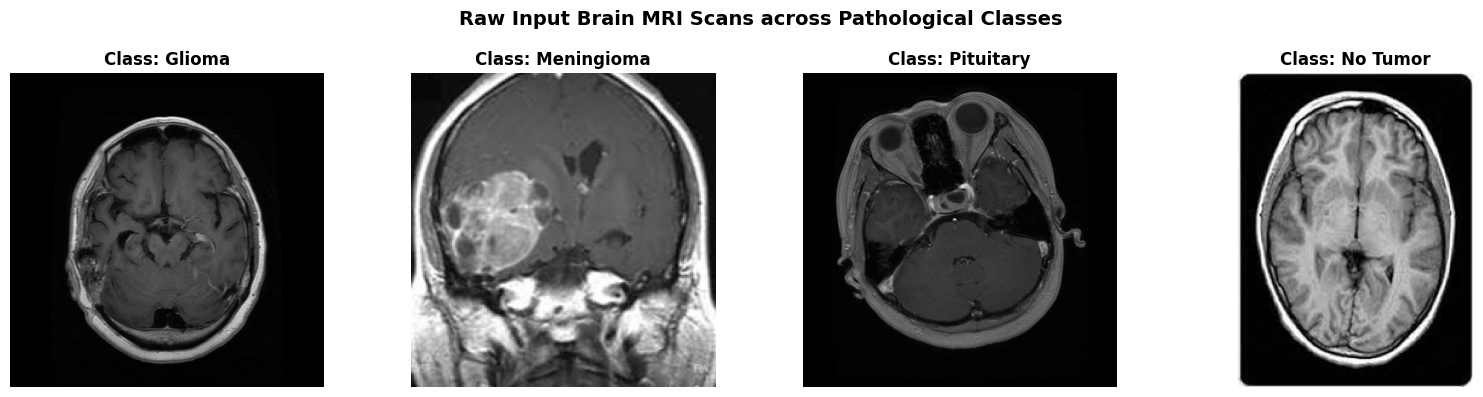

In [ ]:
#  Dataset Scanner & Raw Scans Visualization
extract_path = '/content/drive/MyDrive/DataSet/Brain_Tumor_MRI-20260728T164803Z-1-001/Brain_Tumor_MRI'
valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

image_paths, raw_labels = [], []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(valid_exts):
            full_path = os.path.join(root, file)
            folder_name = os.path.basename(root).lower()
            if 'glioma' in folder_name: label = 'Glioma'
            elif 'meningioma' in folder_name: label = 'Meningioma'
            elif 'pituitary' in folder_name: label = 'Pituitary'
            elif 'no' in folder_name or 'normal' in folder_name: label = 'No Tumor'
            else: continue
            image_paths.append(full_path)
            raw_labels.append(label)

CLASS_NAMES = ['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
labels = np.array([CLASS_TO_IDX[lbl] for lbl in raw_labels])

print(f"[SUCCESS] Total Images Scanned: {len(image_paths)}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls_name in enumerate(CLASS_NAMES):
    cls_indices = np.where(labels == i)[0]
    if len(cls_indices) > 0:
        cls_idx = cls_indices[0]
        sample_img = cv2.imread(image_paths[cls_idx], cv2.IMREAD_GRAYSCALE)
    else:
        sample_img = np.zeros((224, 224), dtype=np.uint8)
    if sample_img is None: sample_img = np.zeros((224, 224), dtype=np.uint8)
    axes[i].imshow(sample_img, cmap='gray')
    axes[i].set_title(f"Class: {cls_name}", fontweight='bold')
    axes[i].axis('off')
plt.suptitle("Raw Input Brain MRI Scans across Pathological Classes", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

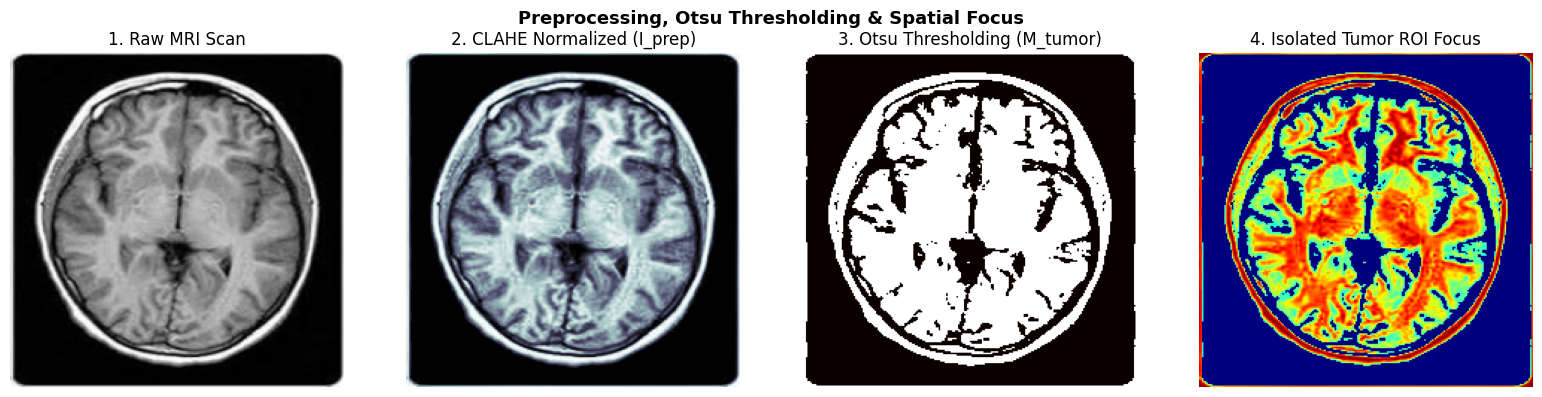

In [ ]:
#  Preprocessing (CLAHE Contrast Adjustment) & Otsu ROI Segmentation
def preprocess_and_Otsu(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.zeros((224, 224), dtype=np.uint8)
    else:
        img = cv2.resize(img, (224, 224))

    # Skull Strip Masking & CLAHE Contrast Enhancement
    _, brain_mask = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)
    img_stripped = cv2.bitwise_and(img, img, mask=brain_mask)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    I_prep = clahe.apply(img_stripped).astype(np.float32) / 255.0

    # Otsu ROI Tumor Mask Generation
    _, M_tumor = cv2.threshold((I_prep * 255).astype(np.uint8), 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return img, I_prep, M_tumor

demo_raw, demo_prep, demo_mask = preprocess_and_Otsu(image_paths[0])
tumor_roi = demo_prep * demo_mask

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(demo_raw, cmap='gray'); axes[0].set_title("1. Raw MRI Scan")
axes[1].imshow(demo_prep, cmap='bone'); axes[1].set_title("2. CLAHE Normalized (I_prep)")
axes[2].imshow(demo_mask, cmap='hot'); axes[2].set_title("3. Otsu Thresholding (M_tumor)")
axes[3].imshow(tumor_roi, cmap='jet'); axes[3].set_title("4. Isolated Tumor ROI Focus")
for ax in axes: ax.axis('off')
plt.suptitle("Preprocessing, Otsu Thresholding & Spatial Focus", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

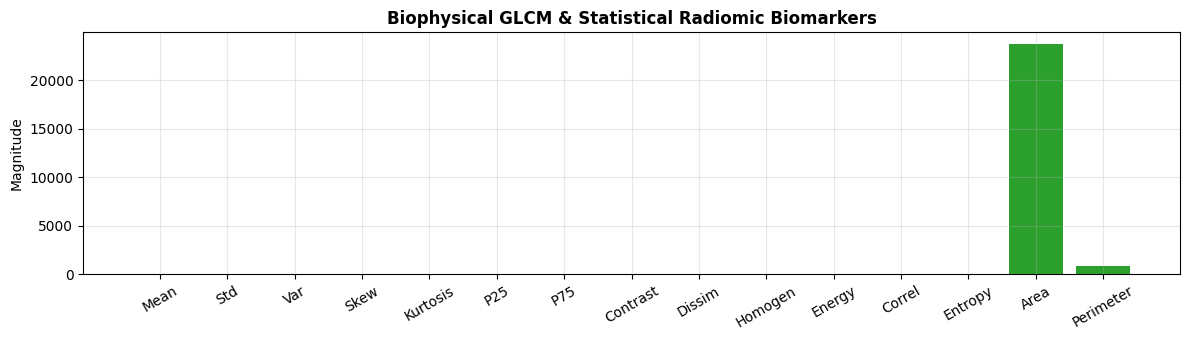

In [ ]:
#  Genuine Biophysical Radiomic Biomarker Extractor (First-Order + GLCM + Shape)
def extract_radiomics_features(I_prep, M_tumor):
    roi = I_prep[M_tumor > 0] if np.sum(M_tumor) > 0 else I_prep.flatten()

    # 1. First-Order Intensity Statistics
    mean = np.mean(roi)
    std = np.std(roi)
    var = np.var(roi)
    skew = np.mean((roi - mean)**3) / (std**3 + 1e-8)
    kurt = np.mean((roi - mean)**4) / (std**4 + 1e-8)
    p25 = np.percentile(roi, 25)
    p75 = np.percentile(roi, 75)

    # 2. GLCM Texture Features
    img_q = (I_prep * 31).astype(np.uint8)
    glcm = graycomatrix(img_q, distances=[1, 2], angles=[0, np.pi/4, np.pi/2], levels=32, symmetric=True, normed=True)

    contrast = np.mean(graycoprops(glcm, 'contrast'))
    dissimilarity = np.mean(graycoprops(glcm, 'dissimilarity'))
    homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))
    energy = np.mean(graycoprops(glcm, 'energy'))
    correlation = np.mean(graycoprops(glcm, 'correlation'))

    # Entropy calculation
    entropy = -np.sum(glcm * np.log2(glcm + 1e-12))

    # 3. Geometric / Shape Biomarkers
    area = float(np.sum(M_tumor))
    contours, _ = cv2.findContours(M_tumor.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    perimeter = cv2.arcLength(contours[0], True) if len(contours) > 0 else 0.0

    features = np.array([mean, std, var, skew, kurt, p25, p75, contrast, dissimilarity, homogeneity, energy, correlation, entropy, area, perimeter], dtype=np.float32)
    return features

demo_radiomics = extract_radiomics_features(demo_prep, demo_mask)
feat_labels = ['Mean', 'Std', 'Var', 'Skew', 'Kurtosis', 'P25', 'P75', 'Contrast', 'Dissim', 'Homogen', 'Energy', 'Correl', 'Entropy', 'Area', 'Perimeter']

plt.figure(figsize=(12, 3.5))
plt.bar(feat_labels, demo_radiomics, color='#2ca02c')
plt.xticks(rotation=30); plt.ylabel('Magnitude')
plt.title('Biophysical GLCM & Statistical Radiomic Biomarkers', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

[INFO] Initializing Deep Vision Model: 'EFFICIENTNET_B0'


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

[INFO] Model Expected Input Resolution: 224x224


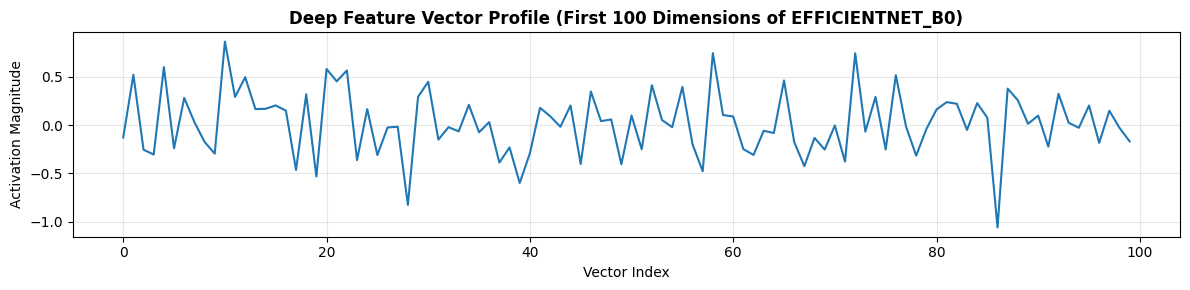

[SUCCESS] Extracted Feature Vector Shape: (768,)


In [ ]:
#  Deep Vision Backbone Extractor (
MODEL_NAME = 'efficientnet_b0' # 'rad_dino', 'resnet50', 'densenet121', 'efficientnet_b0'

class DeepBackboneExtractor(nn.Module):
    def __init__(self, choice='efficientnet_b0', out_dim=768):
        super(DeepBackboneExtractor, self).__init__()
        print(f"[INFO] Initializing Deep Vision Model: '{choice.upper()}'")

        if choice == 'rad_dino':
            self.backbone = timm.create_model("vit_base_patch14_dinov2", pretrained=True, num_classes=0)
        elif choice == 'resnet50':
            self.backbone = timm.create_model('resnet50', pretrained=True, num_classes=0)
        elif choice == 'densenet121':
            self.backbone = timm.create_model('densenet121', pretrained=True, num_classes=0)
        elif choice == 'efficientnet_b0':
            self.backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
        else:
            raise ValueError("Unknown Model Choice!")


        default_cfg = getattr(self.backbone, 'default_cfg', {})
        input_size = default_cfg.get('input_size', (3, 224, 224))
        self.target_size = (input_size[1], input_size[2])
        print(f"[INFO] Model Expected Input Resolution: {self.target_size[0]}x{self.target_size[1]}")

        in_features = self.backbone.num_features
        self.proj = nn.Linear(in_features, out_dim) if in_features != out_dim else nn.Identity()

    def forward(self, x):
        if x.shape[-2:] != self.target_size:
            x = F.interpolate(x, size=self.target_size, mode='bicubic', align_corners=False)
        return self.proj(self.backbone(x))


backbone_dino = DeepBackboneExtractor(choice=MODEL_NAME).to(device)
backbone_dino.eval()

demo_3ch = np.stack([demo_prep]*3, axis=0) # Shape: (3, 224, 224)
demo_tensor = torch.tensor(demo_3ch, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    demo_F_deep = backbone_dino(demo_tensor).cpu().numpy().flatten()

plt.figure(figsize=(12, 3))
plt.plot(demo_F_deep[:100], color='#1f77b4', lw=1.5)
plt.title(f'Deep Feature Vector Profile (First 100 Dimensions of {MODEL_NAME.upper()})', fontsize=12, fontweight='bold')
plt.xlabel('Vector Index'); plt.ylabel('Activation Magnitude')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"[SUCCESS] Extracted Feature Vector Shape: {demo_F_deep.shape}")

In [ ]:
#  Extract Features for Entire Dataset with L2 Normalization
print(f"[INFO] Extracting Features for All {len(image_paths)} Images...")

F_deep_all, R_raw_all = [], []
start_ext_time = time.time()

for idx, path in enumerate(image_paths):
    _, I_prep, M_tumor = preprocess_and_Otsu(path)

    img_3ch = np.stack([I_prep]*3, axis=0)
    tensor_img = torch.tensor(img_3ch, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        f_deep = backbone_dino(tensor_img).cpu().numpy().flatten()
        f_deep = f_deep / (np.linalg.norm(f_deep) + 1e-8) # L2 Normalization

    r_raw = extract_radiomics_features(I_prep, M_tumor)

    F_deep_all.append(f_deep)
    R_raw_all.append(r_raw)

    if (idx + 1) % 1000 == 0 or (idx + 1) == len(image_paths):
        print(f"Processed {idx + 1} / {len(image_paths)} Images...")

F_deep_all = np.array(F_deep_all, dtype=np.float32)
R_raw_all = np.array(R_raw_all, dtype=np.float32)
print(f"[SUCCESS] Feature Extraction Completed in {time.time() - start_ext_time:.2f} seconds.")

[INFO] Extracting Features for All 7200 Images...
Processed 1000 / 7200 Images...
Processed 2000 / 7200 Images...
Processed 3000 / 7200 Images...
Processed 4000 / 7200 Images...
Processed 5000 / 7200 Images...
Processed 6000 / 7200 Images...
Processed 7000 / 7200 Images...
Processed 7200 / 7200 Images...
[SUCCESS] Feature Extraction Completed in 1933.05 seconds.


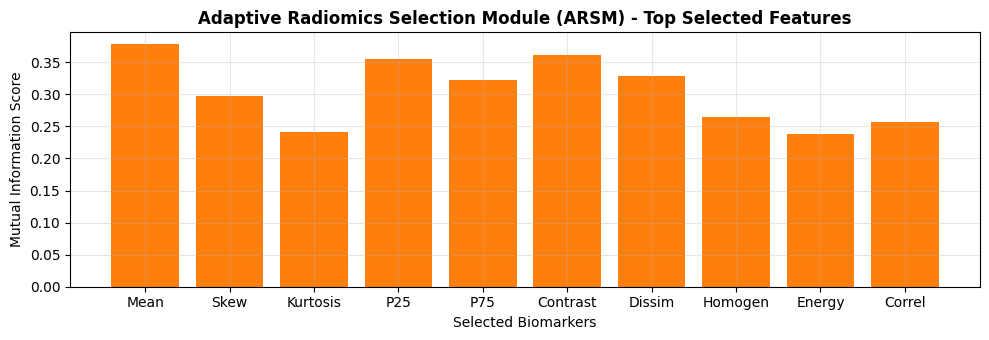

ARSM Complete. Train: 5040 | Val: 1080 | Test: 1080


In [ ]:
#  Adaptive Radiomics Selection Module (ARSM)
F_deep_train, F_deep_temp, R_raw_train, R_raw_temp, y_train, y_temp = train_test_split(
    F_deep_all, R_raw_all, labels, test_size=0.30, random_state=SEED, stratify=labels
)
F_deep_val, F_deep_test, R_raw_val, R_raw_test, y_val, y_test = train_test_split(
    F_deep_temp, R_raw_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Standardize Deep Features
scaler_deep = StandardScaler()
F_deep_train = scaler_deep.fit_transform(F_deep_train)
F_deep_val = scaler_deep.transform(F_deep_val)
F_deep_test = scaler_deep.transform(F_deep_test)

# ARSM: Filter Features -> Select Top 10 Most Information-Rich Features
K_BEST_RAD = 10
arsm_selector = SelectKBest(score_func=mutual_info_classif, k=K_BEST_RAD)
R_sel_train = arsm_selector.fit_transform(R_raw_train, y_train)
R_sel_val = arsm_selector.transform(R_raw_val)
R_sel_test = arsm_selector.transform(R_raw_test)

scaler_rad = StandardScaler()
R_sel_train = scaler_rad.fit_transform(R_sel_train)
R_sel_val = scaler_rad.transform(R_sel_val)
R_sel_test = scaler_rad.transform(R_sel_test)

scores = arsm_selector.scores_[arsm_selector.get_support()]
selected_indices = np.argsort(scores)[::-1]
selected_names = [feat_labels[i] for i in arsm_selector.get_support(indices=True)]

plt.figure(figsize=(10, 3.5))
plt.bar(selected_names, scores, color='#ff7f0e')
plt.xlabel('Selected Biomarkers'); plt.ylabel('Mutual Information Score')
plt.title('Adaptive Radiomics Selection Module (ARSM) - Top Selected Features', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"ARSM Complete. Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")

In [ ]:
#  Gated Attention Fusion & ArcFace Neural Network Architecture
class GatedAttentionFusion(nn.Module):
    def __init__(self, deep_dim=768, rad_dim=10, embed_dim=512):
        super(GatedAttentionFusion, self).__init__()
        self.proj_d = nn.Linear(deep_dim, embed_dim)
        self.proj_r = nn.Linear(rad_dim, embed_dim)

        self.gate = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.Sigmoid()
        )
        self.fusion_layer = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU()
        )

    def forward(self, F_deep, R_sel):
        xd = F.relu(self.proj_d(F_deep))
        xr = F.relu(self.proj_r(R_sel))

        combined = torch.cat([xd, xr], dim=-1)
        z = self.gate(combined)
        fused = z * xd + (1 - z) * xr
        return self.fusion_layer(fused)

class ArcFaceLinear(nn.Module):
    def __init__(self, in_features=512, num_classes=4, s=30.0, m=0.30):
        super(ArcFaceLinear, self).__init__()
        self.s = s; self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features, targets=None):
        cosine = F.linear(F.normalize(features), F.normalize(self.weight))
        if targets is None or not self.training:
            return cosine * self.s
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2)).clamp(0, 1)
        phi = cosine * math.cos(self.m) - sine * math.sin(self.m)
        one_hot = torch.zeros_like(cosine).scatter_(1, targets.view(-1, 1), 1)
        return ((one_hot * phi) + ((1.0 - one_hot) * cosine)) * self.s

class FullBrainTumorModel(nn.Module):
    def __init__(self, num_classes=4, deep_dim=768, rad_dim=10):
        super(FullBrainTumorModel, self).__init__()
        self.fusion = GatedAttentionFusion(deep_dim=deep_dim, rad_dim=rad_dim, embed_dim=512)

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.arcface = ArcFaceLinear(in_features=512, num_classes=num_classes)

    def forward(self, F_deep, R_sel, targets=None):
        refined = self.fusion(F_deep, R_sel)
        logits = self.classifier(refined)
        arc_logits = self.arcface(refined, targets) if self.training else logits
        return logits, arc_logits

print("[INFO] Model Architecture Defined Successfully.")

[INFO] Model Architecture Defined Successfully.


In [ ]:
#  DataLoaders Setup
class BrainDataset(Dataset):
    def __init__(self, f_deep, r_sel, labels):
        self.f_deep = torch.tensor(f_deep, dtype=torch.float32)
        self.r_sel = torch.tensor(r_sel, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.f_deep[idx], self.r_sel[idx], self.labels[idx]

BATCH_SIZE = 32
train_loader = DataLoader(BrainDataset(F_deep_train, R_sel_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(BrainDataset(F_deep_val, R_sel_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(BrainDataset(F_deep_test, R_sel_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print("[INFO] DataLoaders Configured Successfully.")

[INFO] DataLoaders Configured Successfully.


In [ ]:
#  Training Loop
EPOCHS = 50
model = FullBrainTumorModel(num_classes=len(CLASS_NAMES), deep_dim=768, rad_dim=K_BEST_RAD).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_p': [], 'val_p': [],
    'train_r': [], 'val_r': [],
    'train_f1': [], 'val_f1': []
}
best_val_acc = 0.0

print(f"[INFO] Training Model (Backbone: {MODEL_NAME.upper()}) over {EPOCHS} Epochs...\n")
start_train_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, train_preds, train_targets = 0.0, [], []

    for fd, rs, labels_b in train_loader:
        fd, rs, labels_b = fd.to(device), rs.to(device), labels_b.to(device)
        optimizer.zero_grad()

        logits, arc_logits = model(fd, rs, labels_b)

        loss = criterion(logits, labels_b) + 0.5 * criterion(arc_logits, labels_b)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * fd.size(0)
        _, preds = torch.max(logits, 1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels_b.cpu().numpy())

    scheduler.step()

    tr_loss = running_loss / len(y_train)
    tr_acc = accuracy_score(train_targets, train_preds)
    tr_p, tr_r, tr_f1, _ = precision_recall_fscore_support(train_targets, train_preds, average='macro', zero_division=0)

    # Validation Phase
    model.eval()
    val_loss_sum, val_preds, val_targets = 0.0, [], []
    with torch.no_grad():
        for fd, rs, labels_b in val_loader:
            fd, rs, labels_b = fd.to(device), rs.to(device), labels_b.to(device)
            logits, _ = model(fd, rs)
            loss = criterion(logits, labels_b)

            val_loss_sum += loss.item() * fd.size(0)
            _, preds = torch.max(logits, 1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels_b.cpu().numpy())

    val_loss = val_loss_sum / len(y_val)
    val_acc = accuracy_score(val_targets, val_preds)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(val_targets, val_preds, average='macro', zero_division=0)

    history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc); history['val_acc'].append(val_acc)
    history['train_p'].append(tr_p); history['val_p'].append(val_p)
    history['train_r'].append(tr_r); history['val_r'].append(val_r)
    history['train_f1'].append(tr_f1); history['val_f1'].append(val_f1)

    saved_flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'best_{MODEL_NAME}_model.pth')
        saved_flag = f" >>> [NEW BEST VAL ACCURACY]: {best_val_acc*100:.2f}%"

    print(f"Epoch [{epoch:02d}/{EPOCHS}] | "
          f"TRAIN -> Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% P: {tr_p:.4f} R: {tr_r:.4f} F1: {tr_f1:.4f} | "
          f"VAL -> Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% P: {val_p:.4f} R: {val_r:.4f} F1: {val_f1:.4f}{saved_flag}")

print(f"\n[SUCCESS] Completed in {(time.time() - start_train_time)/60:.2f} minutes.")
print(f"[BEST HIGHEST VALIDATION ACCURACY ACHIEVED]: {best_val_acc*100:.2f}%")

[INFO] Training Model (Backbone: EFFICIENTNET_B0) over 50 Epochs...

Epoch [01/50] | TRAIN -> Loss: 1.6958 Acc: 87.30% P: 0.8750 R: 0.8730 F1: 0.8731 | VAL -> Loss: 0.2705 Acc: 90.74% P: 0.9102 R: 0.9074 F1: 0.9065 >>> [NEW BEST VAL ACCURACY]: 90.74%
Epoch [02/50] | TRAIN -> Loss: 0.9855 Acc: 92.64% P: 0.9272 R: 0.9264 F1: 0.9263 | VAL -> Loss: 0.2343 Acc: 91.57% P: 0.9239 R: 0.9157 F1: 0.9153 >>> [NEW BEST VAL ACCURACY]: 91.57%
Epoch [03/50] | TRAIN -> Loss: 0.7074 Acc: 94.88% P: 0.9491 R: 0.9488 F1: 0.9488 | VAL -> Loss: 0.2217 Acc: 93.33% P: 0.9353 R: 0.9333 F1: 0.9335 >>> [NEW BEST VAL ACCURACY]: 93.33%
Epoch [04/50] | TRAIN -> Loss: 0.5592 Acc: 95.67% P: 0.9569 R: 0.9567 F1: 0.9568 | VAL -> Loss: 0.1869 Acc: 93.89% P: 0.9401 R: 0.9389 F1: 0.9390 >>> [NEW BEST VAL ACCURACY]: 93.89%
Epoch [05/50] | TRAIN -> Loss: 0.3844 Acc: 96.98% P: 0.9700 R: 0.9698 F1: 0.9699 | VAL -> Loss: 0.2135 Acc: 93.43% P: 0.9353 R: 0.9343 F1: 0.9343
Epoch [06/50] | TRAIN -> Loss: 0.2812 Acc: 97.84% P: 0.97

In [ ]:
#  Final Test Set Benchmark Evaluation & Inference Speed
model.load_state_dict(torch.load(f'best_{MODEL_NAME}_model.pth'))
model.eval()

y_true, y_pred, y_probs = [], [], []

start_inf_time = time.time()
with torch.no_grad():
    for fd, rs, labels_b in test_loader:
        fd, rs = fd.to(device), rs.to(device)
        logits, _ = model(fd, rs)
        probs = F.softmax(logits, dim=-1)

        y_probs.append(probs.cpu().numpy())
        y_pred.append(torch.argmax(probs, dim=1).cpu().numpy())
        y_true.append(labels_b.numpy())

total_inf_time = (time.time() - start_inf_time) * 1000 # ms
avg_inf_per_image = total_inf_time / len(y_test)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_probs = np.concatenate(y_probs)

test_acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
kappa = cohen_kappa_score(y_true, y_pred)
jaccard = jaccard_score(y_true, y_pred, average='macro')

print("="*65)
print(f"       FINAL BENCHMARK RESULTS (BACKBONE: {MODEL_NAME.upper()})       ")
print("="*65)
print(f" Test Classification Accuracy : {test_acc * 100:.2f} %")
print(f" Macro Precision              : {precision:.4f}")
print(f" Macro Recall (Sensitivity)   : {recall:.4f}")
print(f" Macro F1-Score               : {f1:.4f}")
print(f" Cohen's Kappa Score          : {kappa:.4f}")
print(f" Jaccard Index                : {jaccard:.4f}")
print(f" Inference Latency            : {avg_inf_per_image:.2f} ms / image")
print("="*65)

       FINAL BENCHMARK RESULTS (BACKBONE: EFFICIENTNET_B0)       
 Test Classification Accuracy : 95.74 %
 Macro Precision              : 0.9575
 Macro Recall (Sensitivity)   : 0.9574
 Macro F1-Score               : 0.9574
 Cohen's Kappa Score          : 0.9432
 Jaccard Index                : 0.9190
 Inference Latency            : 0.06 ms / image


       STARTING 5-FOLD STRATIFIED CROSS-VALIDATION EVALUATION       

>>> [FOLD 1/5] Training & Evaluating...
 -> [FOLD 1 RESULT] Acc: 96.81% | Precision: 0.9683 | Recall: 0.9681 | F1: 0.968

>>> [FOLD 2/5] Training & Evaluating...
 -> [FOLD 2 RESULT] Acc: 96.94% | Precision: 0.9698 | Recall: 0.9694 | F1: 0.9694

>>> [FOLD 3/5] Training & Evaluating...
 -> [FOLD 3 RESULT] Acc: 97.29% | Precision: 0.9736 | Recall: 0.9729 | F1: 0.973

>>> [FOLD 4/5] Training & Evaluating...
 -> [FOLD 4 RESULT] Acc: 96.32% | Precision: 0.964 | Recall: 0.9632 | F1: 0.9633

>>> [FOLD 5/5] Training & Evaluating...
 -> [FOLD 5 RESULT] Acc: 96.46% | Precision: 0.9649 | Recall: 0.9646 | F1: 0.9646

            SUMMARY OF 5-FOLD STRATIFIED CROSS-VALIDATION            
  Fold  Accuracy (%)  Precision  Recall  F1-Score
Fold 1         96.81     0.9683  0.9681    0.9680
Fold 2         96.94     0.9698  0.9694    0.9694
Fold 3         97.29     0.9736  0.9729    0.9730
Fold 4         96.32     0.9640  0.9632    0.963

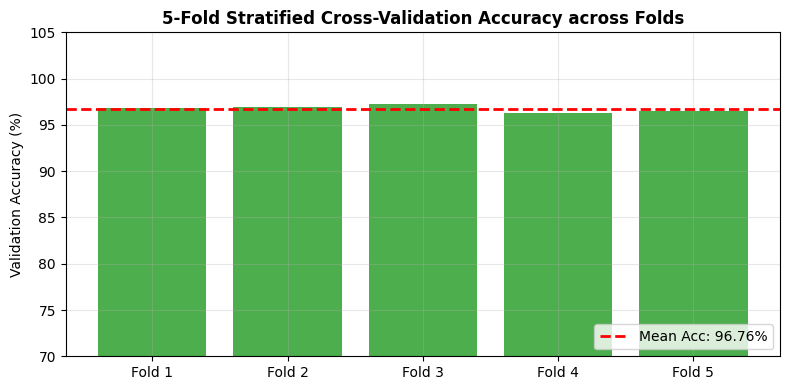

In [ ]:
#  5-Fold Stratified Cross-Validation Evaluation
from sklearn.model_selection import StratifiedKFold

K_FOLDS = 5
FOLD_EPOCHS = 20
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
print("="*75)
print(f"       STARTING {K_FOLDS}-FOLD STRATIFIED CROSS-VALIDATION EVALUATION       ")
print("="*75)

start_kfold_time = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(F_deep_all, labels), 1):
    print(f"\n>>> [FOLD {fold}/{K_FOLDS}] Training & Evaluating...")

    # 1. Train & Val Split for Current Fold
    fd_train_f, fd_val_f = F_deep_all[train_idx], F_deep_all[val_idx]
    rr_train_f, rr_val_f = R_raw_all[train_idx], R_raw_all[val_idx]
    y_train_f, y_val_f = labels[train_idx], labels[val_idx]

    # 2. Standardize Deep Features (Fold-wise to prevent Data Leakage)
    scaler_d_f = StandardScaler()
    fd_train_f = scaler_d_f.fit_transform(fd_train_f)
    fd_val_f = scaler_d_f.transform(fd_val_f)

    # 3. ARSM Feature Selection for Current Fold
    arsm_f = SelectKBest(score_func=mutual_info_classif, k=K_BEST_RAD)
    rs_train_f = arsm_f.fit_transform(rr_train_f, y_train_f)
    rs_val_f = arsm_f.transform(rr_val_f)

    scaler_r_f = StandardScaler()
    rs_train_f = scaler_r_f.fit_transform(rs_train_f)
    rs_val_f = scaler_r_f.transform(rs_val_f)

    # 4. DataLoaders for Current Fold
    train_loader_f = DataLoader(BrainDataset(fd_train_f, rs_train_f, y_train_f), batch_size=BATCH_SIZE, shuffle=True)
    val_loader_f = DataLoader(BrainDataset(fd_val_f, rs_val_f, y_val_f), batch_size=BATCH_SIZE, shuffle=False)

    # 5. Initialize Model Instance for Current Fold
    model_f = FullBrainTumorModel(num_classes=len(CLASS_NAMES), deep_dim=768, rad_dim=K_BEST_RAD).to(device)
    optimizer_f = torch.optim.AdamW(model_f.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler_f = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_f, T_max=FOLD_EPOCHS, eta_min=1e-5)
    criterion_f = nn.CrossEntropyLoss()

    best_fold_acc = 0.0
    best_fold_metrics = {}

    # 6. Fold Training Loop
    for epoch in range(1, FOLD_EPOCHS + 1):
        model_f.train()
        for fd, rs, y_b in train_loader_f:
            fd, rs, y_b = fd.to(device), rs.to(device), y_b.to(device)
            optimizer_f.zero_grad()
            logits, arc_logits = model_f(fd, rs, y_b)
            loss = criterion_f(logits, y_b) + 0.5 * criterion_f(arc_logits, y_b)
            loss.backward()
            optimizer_f.step()
        scheduler_f.step()

        # Fold Validation Phase
        model_f.eval()
        val_preds_f, val_targets_f = [], []
        with torch.no_grad():
            for fd, rs, y_b in val_loader_f:
                fd, rs = fd.to(device), rs.to(device)
                logits, _ = model_f(fd, rs)
                preds = torch.argmax(logits, dim=1)
                val_preds_f.extend(preds.cpu().numpy())
                val_targets_f.extend(y_b.numpy())

        val_acc_f = accuracy_score(val_targets_f, val_preds_f)
        if val_acc_f > best_fold_acc:
            best_fold_acc = val_acc_f
            p, r, f1, _ = precision_recall_fscore_support(val_targets_f, val_preds_f, average='macro', zero_division=0)
            best_fold_metrics = {
                'Fold': f"Fold {fold}",
                'Accuracy (%)': round(val_acc_f * 100, 2),
                'Precision': round(p, 4),
                'Recall': round(r, 4),
                'F1-Score': round(f1, 4)
            }

    fold_results.append(best_fold_metrics)
    print(f" -> [FOLD {fold} RESULT] Acc: {best_fold_metrics['Accuracy (%)']}% | Precision: {best_fold_metrics['Precision']} | Recall: {best_fold_metrics['Recall']} | F1: {best_fold_metrics['F1-Score']}")

# 7. Summary & Mean +/- Std Calculation
df_kfold = pd.DataFrame(fold_results)
mean_acc, std_acc = df_kfold['Accuracy (%)'].mean(), df_kfold['Accuracy (%)'].std()
mean_f1, std_f1 = df_kfold['F1-Score'].mean(), df_kfold['F1-Score'].std()

print("\n" + "="*75)
print("            SUMMARY OF 5-FOLD STRATIFIED CROSS-VALIDATION            ")
print("="*75)
print(df_kfold.to_string(index=False))
print("="*75)
print(f" MEAN ACCURACY : {mean_acc:.2f}% (+/- {std_acc:.2f}%)")
print(f" MEAN F1-SCORE  : {mean_f1:.4f} (+/- {std_f1:.4f})")
print(f" Execution Time: {(time.time() - start_kfold_time)/60:.2f} minutes.")

# Plot K-Fold Accuracy Bar Chart
plt.figure(figsize=(8, 4))
plt.bar(df_kfold['Fold'], df_kfold['Accuracy (%)'], color='#2ca02c', alpha=0.85)
plt.axhline(mean_acc, color='red', linestyle='--', lw=2, label=f'Mean Acc: {mean_acc:.2f}%')
plt.ylabel('Validation Accuracy (%)'); plt.ylim([70, 105])
plt.title('5-Fold Stratified Cross-Validation Accuracy across Folds', fontsize=12, fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

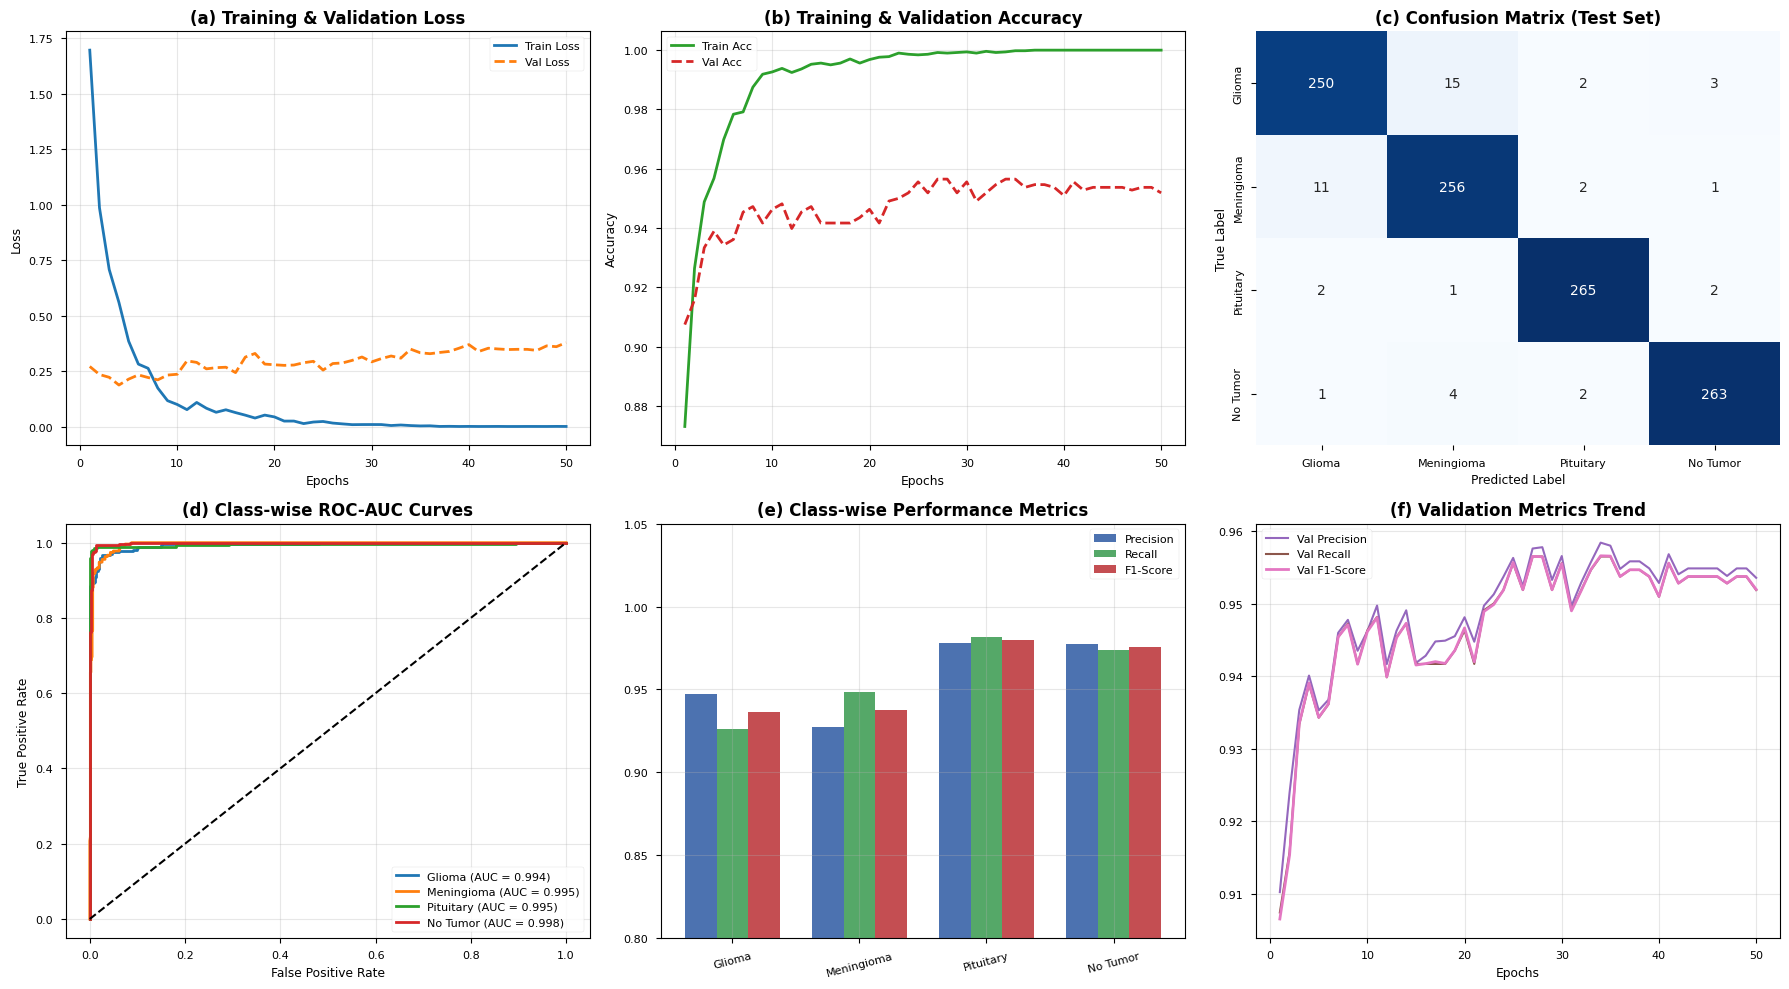

[SUCCESS] Metrics Visualization Saved as 'Results_efficientnet_b0.png'


In [ ]:
# Figures Generation
plt.style.use('seaborn-v0_8-paper')
fig = plt.figure(figsize=(18, 10))

# 1. Loss
ax1 = plt.subplot(2, 3, 1)
ax1.plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
ax1.plot(range(1, EPOCHS + 1), history['val_loss'], label='Val Loss', color='#ff7f0e', linestyle='--', lw=2)
ax1.set_title('(a) Training & Validation Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

# 2. Accuracy
ax2 = plt.subplot(2, 3, 2)
ax2.plot(range(1, EPOCHS + 1), history['train_acc'], label='Train Acc', color='#2ca02c', lw=2)
ax2.plot(range(1, EPOCHS + 1), history['val_acc'], label='Val Acc', color='#d62728', linestyle='--', lw=2)
ax2.set_title('(b) Training & Validation Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix
ax3 = plt.subplot(2, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax3, cbar=False)
ax3.set_title('(c) Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted Label'); ax3.set_ylabel('True Label')

# 4. ROC-AUC
ax4 = plt.subplot(2, 3, 4)
for i in range(len(CLASS_NAMES)):
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax4.plot(fpr, tpr, lw=2, label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})')
ax4.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax4.set_title('(d) Class-wise ROC-AUC Curves', fontsize=12, fontweight='bold')
ax4.set_xlabel('False Positive Rate'); ax4.set_ylabel('True Positive Rate')
ax4.legend(loc='lower right'); ax4.grid(True, alpha=0.3)

# 5. Class Metrics
ax5 = plt.subplot(2, 3, 5)
cls_p, cls_r, cls_f1, _ = precision_recall_fscore_support(y_true, y_pred)
x = np.arange(len(CLASS_NAMES)); width = 0.25
ax5.bar(x - width, cls_p, width, label='Precision', color='#4c72b0')
ax5.bar(x, cls_r, width, label='Recall', color='#55a868')
ax5.bar(x + width, cls_f1, width, label='F1-Score', color='#c44e52')
ax5.set_xticks(x); ax5.set_xticklabels(CLASS_NAMES, rotation=15)
ax5.set_ylim([0.8, 1.05])
ax5.set_title('(e) Class-wise Performance Metrics', fontsize=12, fontweight='bold')
ax5.legend(); ax5.grid(True, alpha=0.3)

# 6. Precision-Recall Score Trend
ax6 = plt.subplot(2, 3, 6)
ax6.plot(range(1, EPOCHS + 1), history['val_p'], label='Val Precision', color='#9467bd', lw=1.5)
ax6.plot(range(1, EPOCHS + 1), history['val_r'], label='Val Recall', color='#8c564b', lw=1.5)
ax6.plot(range(1, EPOCHS + 1), history['val_f1'], label='Val F1-Score', color='#e377c2', lw=2)
ax6.set_title('(f) Validation Metrics Trend', fontsize=12, fontweight='bold')
ax6.set_xlabel('Epochs'); ax6.legend(); ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'Results_{MODEL_NAME}.png', dpi=300)
plt.show()

print(f"[SUCCESS] Metrics Visualization Saved as 'Results_{MODEL_NAME}.png'")

                 ABLATION STUDY EVALUATION                 
 -> 1. Full Model (efficientnet_b0 + ARSM Radiomics) | Acc: 95.74% | F1: 0.9574
 -> 2. w/o Radiomics Stream (efficientnet_b0 Only)   | Acc: 91.39% | F1: 0.9138
 -> 3. w/o Deep Stream (ARSM Radiomics Only)         | Acc: 32.78% | F1: 0.2322


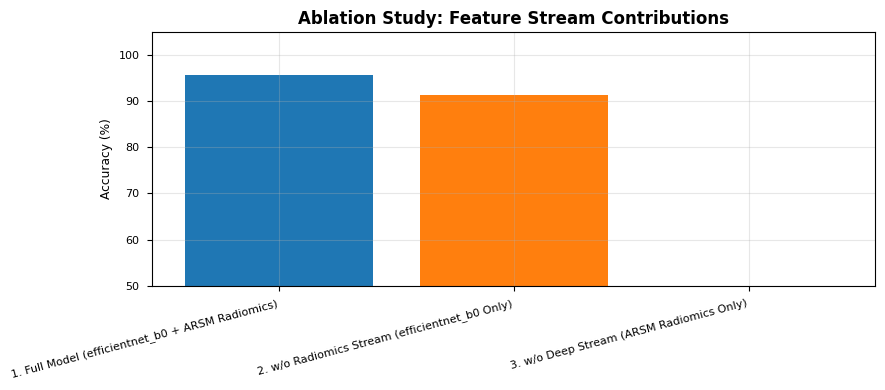

In [ ]:
#  Ablation Study Evaluation
def run_ablation_study(trained_model, test_loader, device):
    trained_model.eval()

    configs = [
        {"name": "1. Full Model (efficientnet_b0 + ARSM Radiomics)", "mask_d": False, "mask_r": False},
        {"name": "2. w/o Radiomics Stream (efficientnet_b0 Only)", "mask_d": False, "mask_r": True},
        {"name": "3. w/o Deep Stream (ARSM Radiomics Only)", "mask_d": True, "mask_r": False},
    ]

    results = []
    print("="*75)
    print("                 ABLATION STUDY EVALUATION                 ")
    print("="*75)

    for config in configs:
        y_true_abl, y_pred_abl = [], []
        with torch.no_grad():
            for fd, rs, labels_b in test_loader:
                fd, rs = fd.to(device), rs.to(device)

                fd_inp = torch.zeros_like(fd) if config["mask_d"] else fd
                fr_inp = torch.zeros_like(rs) if config["mask_r"] else rs

                logits, _ = trained_model(fd_inp, fr_inp)
                probs = F.softmax(logits, dim=-1)

                y_pred_abl.extend(torch.argmax(probs, dim=1).cpu().numpy())
                y_true_abl.extend(labels_b.numpy())

        acc = accuracy_score(y_true_abl, y_pred_abl) * 100
        p, r, f1, _ = precision_recall_fscore_support(y_true_abl, y_pred_abl, average='macro', zero_division=0)

        results.append({
            "Configuration": config["name"],
            "Accuracy (%)": round(acc, 2),
            "Precision": round(p, 4),
            "Recall": round(r, 4),
            "F1-Score": round(f1, 4)
        })
        print(f" -> {config['name']:<48} | Acc: {acc:.2f}% | F1: {f1:.4f}")

    df_abl = pd.DataFrame(results)

    plt.figure(figsize=(9, 4))
    plt.bar(df_abl['Configuration'], df_abl['Accuracy (%)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.ylabel('Accuracy (%)'); plt.ylim([50, 105])
    plt.xticks(rotation=15, ha='right')
    plt.title('Ablation Study: Feature Stream Contributions', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    return df_abl

df_ablation = run_ablation_study(model, test_loader, device)

In [ ]:
#  Tumor Focus Region Visualizer & Inference
def detect_and_visualize_tumor_focus(image_path):
    if not os.path.exists(image_path):
        print(f" File not found: '{image_path}'")
        return

    # 1. Preprocess & Otsu Segmentation
    raw_i, prep_i, mask_i = preprocess_and_Otsu(image_path)

    # 2. Extract Features
    r_raw = extract_radiomics_features(prep_i, mask_i)
    Fr = scaler_rad.transform(arsm_selector.transform(r_raw.reshape(1, -1)))

    img_3ch = np.stack([prep_i]*3, axis=0)
    tensor_img = torch.tensor(img_3ch, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        fd = backbone_dino(tensor_img).cpu().numpy().flatten()
        fd = fd / (np.linalg.norm(fd) + 1e-8)
    Fd = scaler_deep.transform(fd.reshape(1, -1))

    # 3. Model Forward Pass
    model.eval()
    fd_t = torch.tensor(Fd, dtype=torch.float32).to(device)
    fr_t = torch.tensor(Fr, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits, _ = model(fd_t, fr_t)
        probs = F.softmax(logits, dim=-1)[0].cpu().numpy() * 100

    pred_idx = np.argmax(probs)
    pred_class = CLASS_NAMES[pred_idx]

    # 4. Generate ROI Density Focus Map
    focus_map = cv2.GaussianBlur(prep_i * mask_i, (21, 21), 0)
    focus_map = (focus_map - np.min(focus_map)) / (np.max(focus_map) - np.min(focus_map) + 1e-8)

    fig = plt.figure(figsize=(15, 4))

    ax1 = plt.subplot(1, 3, 1)
    ax1.imshow(prep_i, cmap='gray'); ax1.imshow(mask_i, cmap='jet', alpha=0.35)
    ax1.set_title("1. Otsu Grounded Tumor ROI Mask", fontweight='bold'); ax1.axis('off')

    ax2 = plt.subplot(1, 3, 2)
    ax2.imshow(prep_i, cmap='gray'); ax2.imshow(focus_map, cmap='hot', alpha=0.55)
    ax2.set_title("2. Isolated Tumor Focus Region", fontweight='bold'); ax2.axis('off')

    ax3 = plt.subplot(1, 3, 3)
    ax3.bar(CLASS_NAMES, probs, color=['#1f77b4' if i!=pred_idx else '#d62728' for i in range(4)])
    ax3.set_ylabel('Probability (%)'); ax3.set_ylim([0, 105])
    ax3.set_title(f"Predicted Class: {pred_class}\nCertainty: {probs[pred_idx]:.2f}%", fontweight='bold')
    ax3.grid(True, alpha=0.3)

    plt.suptitle(f"================ TUMOR DETECTION & DIAGNOSIS: {os.path.basename(image_path)} ================", fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f" DETECTED DIAGNOSIS: {pred_class.upper()} ({probs[pred_idx]:.2f}% Confidence)")



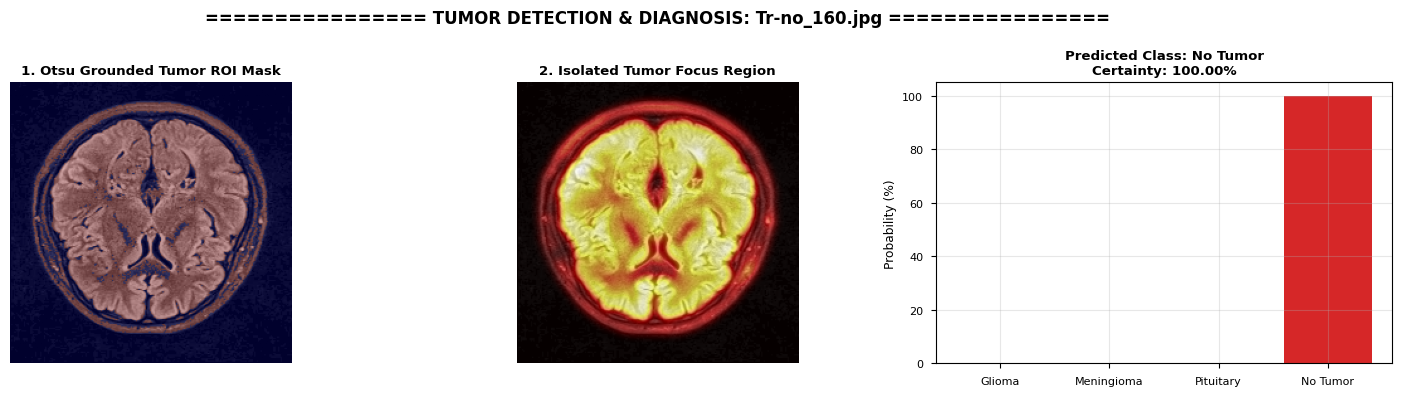

 DETECTED DIAGNOSIS: NO TUMOR (100.00% Confidence)


In [ ]:
# Run demo on first sample
detect_and_visualize_tumor_focus(image_paths[50])